In [22]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
import matplotlib.pyplot as plt


In [15]:
# data based on imputed_full_2022_2025_with_air_zones.csv from Andy's notebook
df = pd.read_csv("imputed_full_2022_2025_with_air_zones.csv", parse_dates=['Datetime'], index_col='Datetime')
print(df.head())
print(df.info())

                                          Station       PM25   Latitude  \
Datetime                                                                  
2022-01-01 01:00:00  Abbotsford A Columbia Street   2.840752  49.021500   
2022-01-01 01:00:00            Abbotsford Central  14.556050  49.042600   
2022-01-01 01:00:00       Burnaby Kensington Park  11.800620  49.279200   
2022-01-01 01:00:00                 Burnaby South   3.421575  49.215200   
2022-01-01 01:00:00        Burns Lake Fire Centre   3.517412  54.230731   

                      Longitude    Official_Air_Zone  
Datetime                                              
2022-01-01 01:00:00 -122.326500  Lower Fraser Valley  
2022-01-01 01:00:00 -122.309800  Lower Fraser Valley  
2022-01-01 01:00:00 -122.970700  Lower Fraser Valley  
2022-01-01 01:00:00 -122.985700  Lower Fraser Valley  
2022-01-01 01:00:00 -125.764354     Central Interior  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1753200 entries, 2022-01-01 01:00:00

In [18]:
df_wide = df.groupby(['Datetime', 'Official_Air_Zone'])['PM25'].median().unstack()
print(df_wide.head())
print(df_wide.info())



Official_Air_Zone    Central Interior   Coastal  Georgia Strait  \
Datetime                                                          
2022-01-01 01:00:00          4.731367  6.000000       15.670830   
2022-01-01 02:00:00          3.769583  4.500000       20.313885   
2022-01-01 03:00:00          3.470026  2.500000        7.221611   
2022-01-01 04:00:00          3.412444  1.700476        6.538530   
2022-01-01 05:00:00          3.127457  2.500000        3.593097   

Official_Air_Zone    Lower Fraser Valley  Northeast  Southern Interior  
Datetime                                                                
2022-01-01 01:00:00             6.351373   7.575757           17.65353  
2022-01-01 02:00:00             6.299942   7.612401           16.96961  
2022-01-01 03:00:00             5.474733   7.691798           12.14052  
2022-01-01 04:00:00             4.187194   7.487464           11.37136  
2022-01-01 05:00:00             3.418764   7.434292           11.48632  
<class 'pandas.core

In [21]:
df_wide.index = pd.date_range(start='2022-01-01 01:00:00', periods=len(df_wide), freq='h')
print(df_wide.head())

Official_Air_Zone    Central Interior   Coastal  Georgia Strait  \
2022-01-01 01:00:00          4.731367  6.000000       15.670830   
2022-01-01 02:00:00          3.769583  4.500000       20.313885   
2022-01-01 03:00:00          3.470026  2.500000        7.221611   
2022-01-01 04:00:00          3.412444  1.700476        6.538530   
2022-01-01 05:00:00          3.127457  2.500000        3.593097   

Official_Air_Zone    Lower Fraser Valley  Northeast  Southern Interior  
2022-01-01 01:00:00             6.351373   7.575757           17.65353  
2022-01-01 02:00:00             6.299942   7.612401           16.96961  
2022-01-01 03:00:00             5.474733   7.691798           12.14052  
2022-01-01 04:00:00             4.187194   7.487464           11.37136  
2022-01-01 05:00:00             3.418764   7.434292           11.48632  


In [36]:
def walk_forward_validation(series, train_size=1500, horizon=3, n_splits=5):
    """
    Performs rolling forecast validation.
    
    Args:
        series: Pandas Series of the region data
        train_size: Number of hours to use for training (sliding window)
        horizon: Number of hours to forecast ahead
        n_splits: Number of times to slide the window (to save time)
    """
    history = series.values
    predictions = []
    actuals = []
    
    # Start index: We need at least 'train_size' data points before we can start
    # We will test on the *last* available data in the series
    total_test_points = n_splits * horizon
    start_index = len(history) - total_test_points - train_size

    if start_index < 0:
        print(f"  [!] Not enough data. Need {train_size + total_test_points} rows.")
        return None

    print(f"  > Starting validation on last {total_test_points} hours...")

    for i in range(n_splits):
        # 1. Define Sliding Window
        # Window start moves forward by 'horizon' steps each iteration
        t_start = start_index + (i * horizon)
        t_end = t_start + train_size
        
        train_data = history[t_start : t_end]
        actual_data = history[t_end : t_end + horizon]
        
        # 2. Fit Model
        # Using a simpler Order for speed. 
        # TIP: Use auto_arima to find best (p,d,q) for each region separately if possible.
        model = SARIMAX(train_data, 
                        order=(1, 1, 1), 
                        seasonal_order=(2, 1, 0, 24), # Set seasonal_order=(1,1,1,24) for full run
                        enforce_stationarity=False, 
                        enforce_invertibility=False)
        
        model_fit = model.fit(disp=False)
        
        # 3. Forecast
        pred = model_fit.forecast(steps=horizon)
        
        # 4. Store
        predictions.extend(pred)
        actuals.extend(actual_data)
        
        # Optional: Print progress
        # print(f"    Split {i+1}/{n_splits}: Actual {actual_data} vs Pred {pred}")

    # 5. Calculate Metrics
    rmse = math.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    
    return rmse, mae, actuals, predictions


In [ ]:

# ---------------------------------------------------------
# 3. RUN FOR ALL REGIONS
# ---------------------------------------------------------
results_table = []

# List of regions (columns)
regions = ['Central Interior', 'Coastal', 'Georgia Strait', 
           'Lower Fraser Valley', 'Northeast', 'Southern Interior']

print(f"Data shape: {df.shape}")
print("Running Walk-Forward Validation (Train=1500, Horizon=3)...\n")

for region in regions:
    print(f"Processing: {region}")
    
    # Run Validation
    # NOTE: n_splits=5 means we only test 5 intervals (15 hours total) to keep this script fast.
    # Increase n_splits to cover more of your 2026 data.
    res = walk_forward_validation(df_wide[region], train_size=1500, horizon=3, n_splits=5)
    
    if res:
        rmse, mae, _, _ = res
        results_table.append({
            'Region': region,
            'RMSE': round(rmse, 4),
            'MAE': round(mae, 4)
        })
        print(f"  -> RMSE: {rmse:.4f} | MAE: {mae:.4f}\n")

# ---------------------------------------------------------
# 4. FINAL SUMMARY
# ---------------------------------------------------------
results_df = pd.DataFrame(results_table)
print("--- Final Accuracy Report ---")
print(results_df)

Visualizing results for: Central Interior
  > Starting validation on last 18 hours...


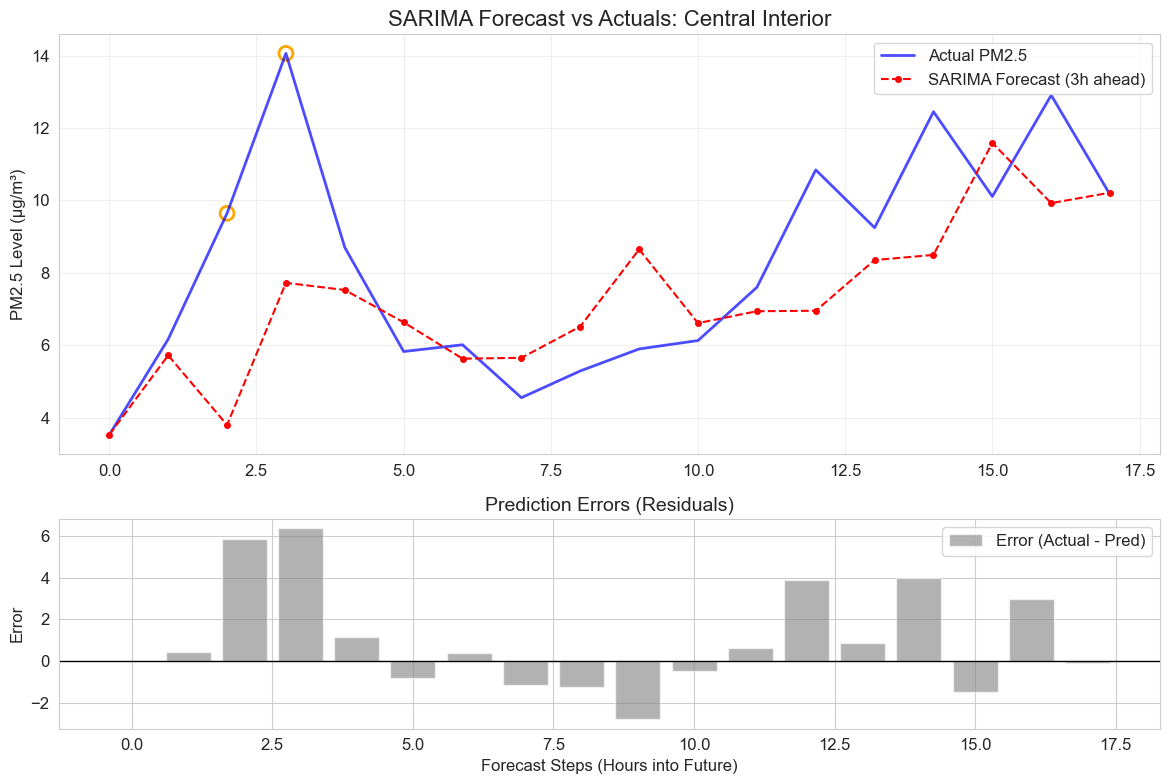

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP PLOTTING STYLE
sns.set_style("whitegrid")
plt.rcParams.update({'figure.figsize': (12, 8), 'font.size': 12})

# 2. SELECT REGION & GET DATA
target_region = 'Central Interior'
print(f"Visualizing results for: {target_region}")

# Run validation specifically to get the plotting data
# (Assuming 'walk_forward_validation' and 'df' are defined from the previous step)
# Increased n_splits to 24 (validating 72 hours / 3 days) for a better visual
rmse, mae, actuals, preds = walk_forward_validation(df_wide[target_region], 
                                                    train_size=1500, 
                                                    horizon=3, 
                                                    n_splits=6)

# 3. CREATE PLOTS
fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=[2, 1])

# --- Plot 1: Actual vs Predicted Time Series ---
# Creating a dummy hourly index for the plot X-axis
time_steps = range(len(actuals))

ax1.plot(time_steps, actuals, label='Actual PM2.5', color='blue', linewidth=2, alpha=0.7)
ax1.plot(time_steps, preds, label='SARIMA Forecast (3h ahead)', color='red', linestyle='--', marker='.', markersize=8)

ax1.set_title(f'SARIMA Forecast vs Actuals: {target_region}', fontsize=16)
ax1.set_ylabel('PM2.5 Level (µg/m³)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Highlight significant deviations?
# Iterate through points and circle where error > 5 units (optional visual aid)
for t, act, pre in zip(time_steps, actuals, preds):
    if abs(act - pre) > 5.0:
        ax1.scatter(t, act, s=100, facecolors='none', edgecolors='orange', linewidth=2, label='High Error' if 'High Error' not in [l.get_label() for l in ax1.get_lines()] else "")

# --- Plot 2: Residuals (Actual - Predicted) ---
residuals = [a - p for a, p in zip(actuals, preds)]
ax2.bar(time_steps, residuals, color='gray', alpha=0.6, label='Error (Actual - Pred)')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Prediction Errors (Residuals)', fontsize=14)
ax2.set_xlabel('Forecast Steps (Hours into Future)')
ax2.set_ylabel('Error')
ax2.legend()

plt.tight_layout()
plt.show()

In [33]:
# use (Auto-ARIMA) to find best (p,d,q) for each region separately if possible.
# You may need to install this: pip install pmdarima
import pmdarima as pm

# Take a sample of your data (e.g., last 500 hours) to train
train_sample = df_wide['Central Interior'].tail(500)

# Auto-tune
model = pm.auto_arima(train_sample,
                      start_p=1, start_q=1,
                      max_p=5, max_q=5,      # Allow higher AR lag to catch spikes
                      m=24,                  # Seasonality (Daily cycle)
                      start_P=0, seasonal=True,
                      d=1, D=1,              # Force differencing to handle trends
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[24]             : AIC=inf, Time=14.78 sec
 ARIMA(0,1,0)(0,1,0)[24]             : AIC=2466.604, Time=0.10 sec
 ARIMA(1,1,0)(1,1,0)[24]             : AIC=2263.675, Time=1.57 sec
 ARIMA(0,1,1)(0,1,1)[24]             : AIC=inf, Time=6.87 sec
 ARIMA(1,1,0)(0,1,0)[24]             : AIC=2437.985, Time=0.08 sec
 ARIMA(1,1,0)(2,1,0)[24]             : AIC=2222.644, Time=3.55 sec
 ARIMA(1,1,0)(2,1,1)[24]             : AIC=inf, Time=37.52 sec
 ARIMA(1,1,0)(1,1,1)[24]             : AIC=inf, Time=8.80 sec
 ARIMA(0,1,0)(2,1,0)[24]             : AIC=2248.474, Time=2.06 sec
 ARIMA(2,1,0)(2,1,0)[24]             : AIC=2220.639, Time=4.32 sec
 ARIMA(2,1,0)(1,1,0)[24]             : AIC=2262.152, Time=0.84 sec
 ARIMA(2,1,0)(2,1,1)[24]             : AIC=inf, Time=27.83 sec
 ARIMA(2,1,0)(1,1,1)[24]             : AIC=inf, Time=11.36 sec
 ARIMA(3,1,0)(2,1,0)[24]             : AIC=2222.178, Time=4.74 sec
 ARIMA(2,1,1)(2,1,0)[24]             : AIC=in